# Explainable Wildlife Recognition (Grad-CAM)
This notebook implements Explainable AI using Grad-CAM. It takes an image, runs prediction through your final EfficientNet model, and shows a heatmap of *why* it made that decision visually directly inside Colab.

In [1]:
# Mount Google Drive to access your model
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies if not present
!pip install -q opencv-python matplotlib numpy

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
import cv2

MODEL_PATH = "/content/drive/MyDrive/DL-pro_dataset/animals_best.keras"
IMG_SIZE = 128

CLASS_NAMES = [
    'antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison',
    'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach',
    'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey',
    'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox',
    'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster',
    'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird',
    'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard',
    'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus',
    'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot',
    'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum',
    'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse',
    'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel',
    'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf',
    'wombat', 'woodpecker', 'zebra'
]

def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img, img_array

def display_gradcam_overlay(img, heatmap, top_classes, top_probs, alpha=0.4):
    img_array = image.img_to_array(img)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap_jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_jet = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)
    superimposed_img = heatmap_jet * alpha + img_array
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Wildlife Transparent Prediction Explainability", fontsize=16, fontweight='bold')

    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title("Original Image", fontsize=14)

    axes[1].imshow(superimposed_img)
    axes[1].axis('off')
    title_text = f"Explained: What the model looked at\nTop Prediction: {top_classes[0]} ({top_probs[0]:.1f}%)"
    axes[1].set_title(title_text, fontsize=14)

    plt.tight_layout()
    # Note: plt.show() works seamlessly in Colab to render images inline
    plt.show()

def predict_explainable(img_path, model):
    print(f"Analyzing Image: {os.path.basename(img_path)}")
    img, img_array = load_and_preprocess_image(img_path)
    predictions = model.predict(img_array, verbose=0)[0]

    top_3_indices = np.argsort(predictions)[-3:][::-1]
    top_classes = [CLASS_NAMES[i] for i in top_3_indices]
    top_probs = [predictions[i] * 100 for i in top_3_indices]

    print("\n--- Model Predictions ---")
    for i in range(3):
        prefix = ">> Top-1 (Winner):" if i == 0 else f"   Top-{i+1}:         "
        print(f"{prefix} {top_classes[i].capitalize()} ({top_probs[i]:.2f}%)")

    last_conv_layer = get_last_conv_layer_name(model)
    if not last_conv_layer:
        print("No Conv2D layer found to explain.")
        return

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)
    display_gradcam_overlay(img, heatmap, top_classes, top_probs)


In [3]:
# Load Model block
print(f"Loading model from {MODEL_PATH}...")
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print("Error loading model:", e)


Loading model from /content/drive/MyDrive/DL-pro_dataset/animals_best.keras...
Model loaded successfully!


Analyzing Image: WhatsApp Image 2025-09-03 at 19.24.03_9eb0509d.jpg

--- Model Predictions ---
>> Top-1 (Winner): Fox (98.42%)
   Top-2:          Coyote (0.74%)
   Top-3:          Squirrel (0.50%)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


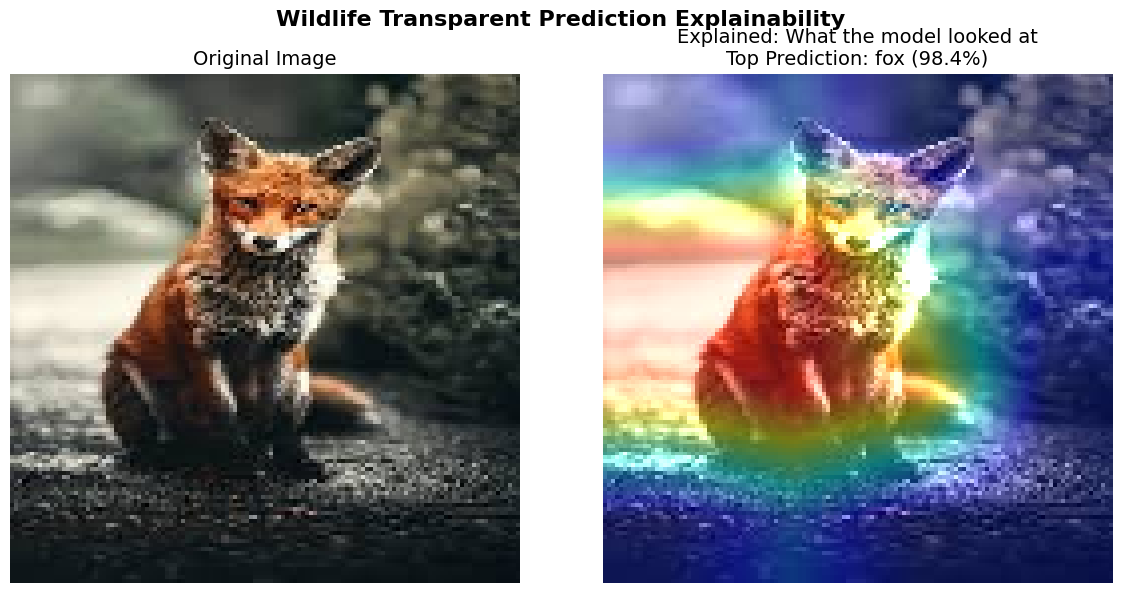

In [4]:
# Test on an image from the test set
test_image_dir = "/content/drive/MyDrive/DL-pro_dataset/test_images"
sample_image = os.path.join(test_image_dir, "WhatsApp Image 2025-09-03 at 19.24.03_9eb0509d.jpg")

if os.path.exists(sample_image):
    predict_explainable(sample_image, model)
else:
    print(f"Target image not found at {sample_image}. Please update path.")
